# Data Exploration

Visualizing waveforms and spectrograms from the RAVDESS dataset.

In [13]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Determine path to a sample file
data_path = '../RAVDESS'
sample_file = None

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            sample_file = os.path.join(root, file)
            break
    if sample_file:
        break

if sample_file:
    print(f"Loading: {sample_file}")
    y, sr = librosa.load(sample_file)
else:
    print("No wav file found in ../RAVDESS")

Loading: ../RAVDESS\Actor_01\03-01-01-01-01-01-01.wav


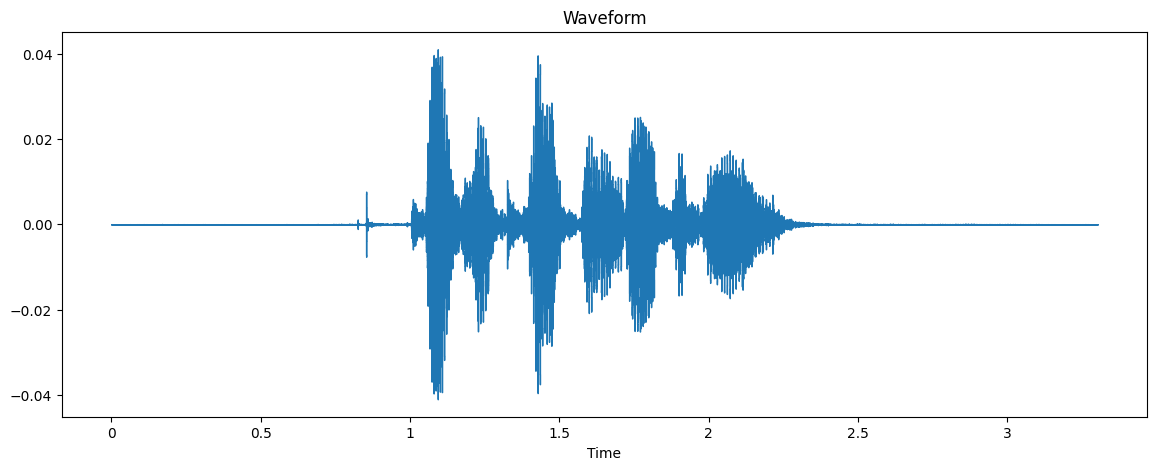

In [14]:
# Waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.show()

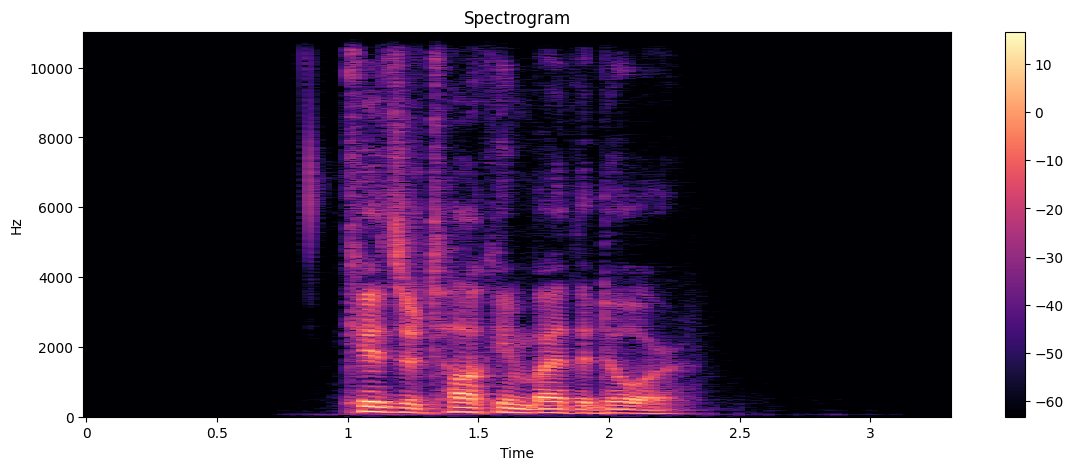

In [15]:
# Spectrogram
X = librosa.stft(y)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title('Spectrogram')
plt.show()

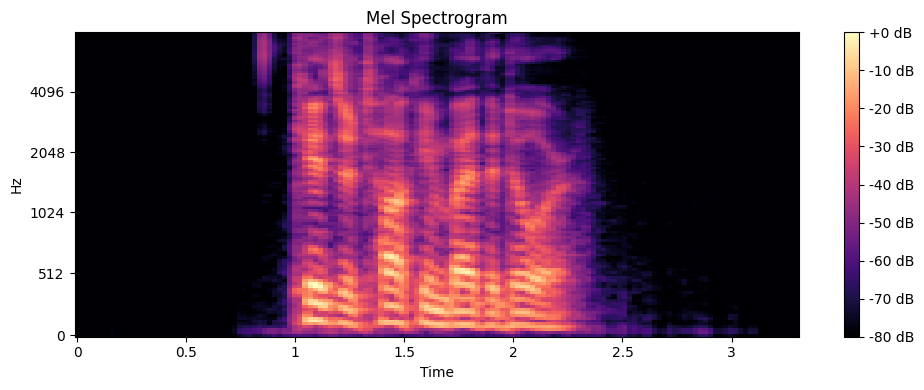

In [16]:
# Mel Spectrogram
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spect_db, y_axis='mel', fmax=8000, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()